## Load Data

In [ ]:
import zipfile
import os


zip_file_path = '/content/20sample_sf.zip'
extract_dir = '/content/street_fighter_data'

os.makedirs(extract_dir, exist_ok=True)

#open the zip file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print(f"Extracted contents from '{zip_file_path}' to '{extract_dir}' directory.")


Extracted contents from '/content/20sample_sf.zip' to '/content/street_fighter_data' directory.


## Dataset distribution

Scanning dataset...

===== GLOBAL STATS =====
Total samples: 12269
Average length: 19.53
Median length: 20.00
Min length: 1
Max length: 60

Percentiles:
25th percentile: 19.00
50th percentile: 20.00
75th percentile: 20.00
90th percentile: 20.00

===== PER-CLASS STATS =====

JAB
  Count: 1340
  Avg: 19.69
  Median: 20.00
  Min: 5
  Max: 20

LEFT_GUARD
  Count: 1405
  Avg: 19.74
  Median: 20.00
  Min: 15
  Max: 20

LEFT_HOOK
  Count: 1385
  Avg: 19.56
  Median: 20.00
  Min: 18
  Max: 20

LEFT_UPPER
  Count: 1307
  Avg: 19.73
  Median: 20.00
  Min: 1
  Max: 20

PROTECT_LEFT
  Count: 1308
  Avg: 19.54
  Median: 20.00
  Min: 19
  Max: 20

PROTECT_RIGHT
  Count: 1097
  Avg: 19.55
  Median: 20.00
  Min: 10
  Max: 20

PUNCH
  Count: 1106
  Avg: 19.17
  Median: 20.00
  Min: 1
  Max: 22

RIGHT_GUARD
  Count: 1102
  Avg: 19.26
  Median: 20.00
  Min: 1
  Max: 60

RIGHT_HOOK
  Count: 1110
  Avg: 19.49
  Median: 20.00
  Min: 4
  Max: 20

RIGHT_UPPER
  Count: 1109
  Avg: 19.38
  Median: 20.00
  Min: 

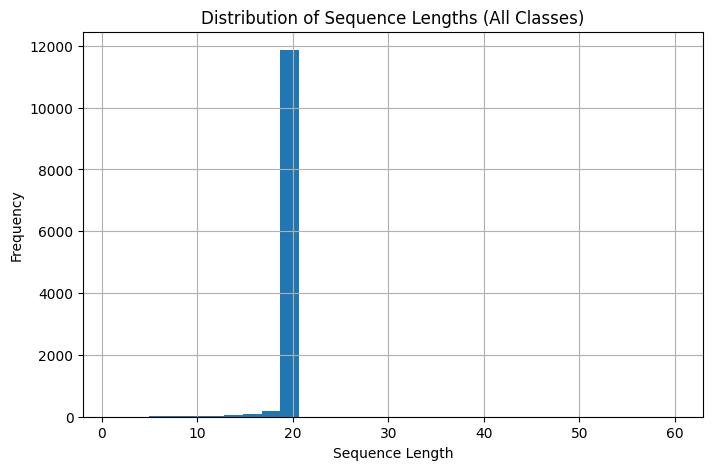

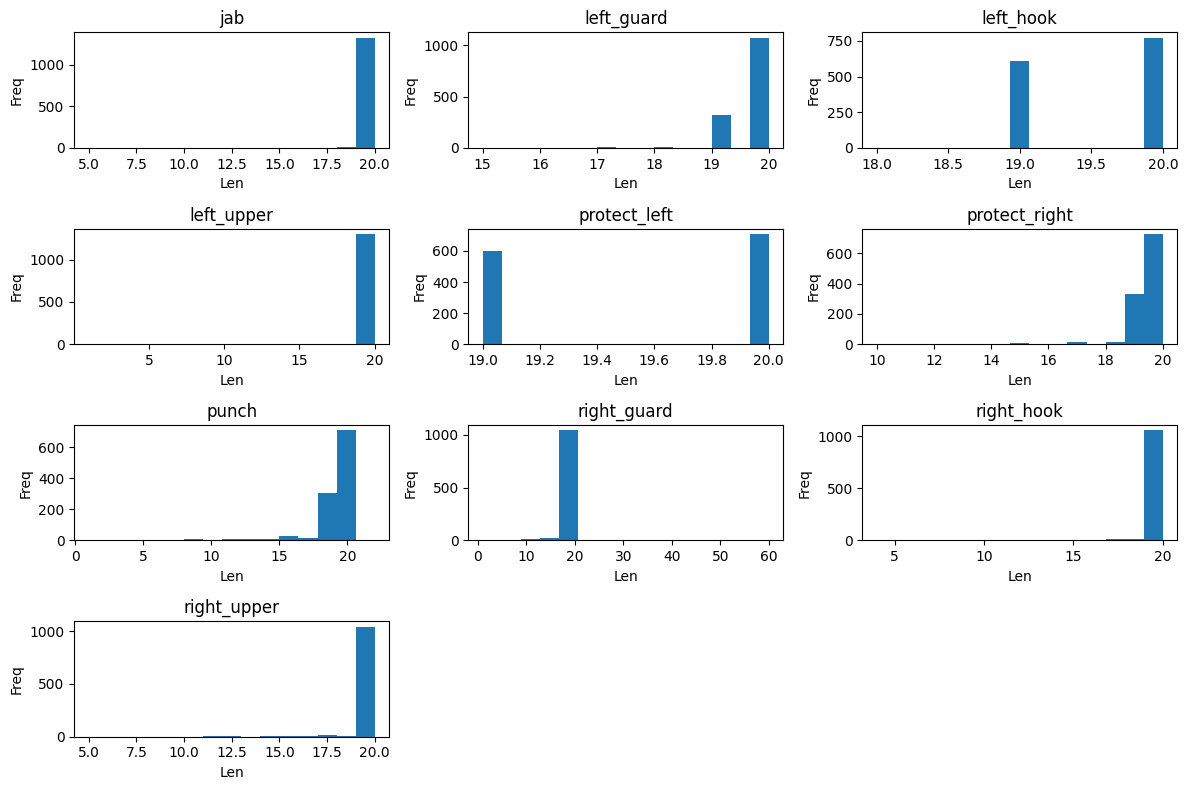


===== RECOMMENDATION =====
Suggested TARGET_ROWS ≈ 20

Guideline:
- Use median (more robust than mean)
- Round to nearest 5 or 10 for clean CNN size
- Your current choice (125) is good if close to this value


In [ ]:
import pandas as pd
import numpy as np
import glob
import os
import matplotlib.pyplot as plt

#config
base_path = "/content/street_fighter_data/combined_final_clear"
ACTIONS = ['jab', 'left_guard', 'left_hook', 'left_upper', 'protect_left',
           'protect_right', 'punch', 'right_guard', 'right_hook', 'right_upper']

#collect lengths
all_lengths = []
class_lengths = {action: [] for action in ACTIONS}

print("Scanning dataset...")

for folder in ACTIONS:
    folder_path = os.path.join(base_path, folder)
    csv_files = glob.glob(os.path.join(folder_path, "*.csv"))

    for file in csv_files:
        try:
            df = pd.read_csv(file)
            df.columns = df.columns.str.strip()

            length = len(df)

            all_lengths.append(length)
            class_lengths[folder].append(length)

        except Exception as e:
            print(f"Error reading {file}: {e}")

all_lengths = np.array(all_lengths)

#Global stats
print("\n===== GLOBAL STATS =====")
print(f"Total samples: {len(all_lengths)}")
print(f"Average length: {all_lengths.mean():.2f}")
print(f"Median length: {np.median(all_lengths):.2f}")
print(f"Min length: {all_lengths.min()}")
print(f"Max length: {all_lengths.max()}")

print("\nPercentiles:")
print(f"25th percentile: {np.percentile(all_lengths, 25):.2f}")
print(f"50th percentile: {np.percentile(all_lengths, 50):.2f}")
print(f"75th percentile: {np.percentile(all_lengths, 75):.2f}")
print(f"90th percentile: {np.percentile(all_lengths, 90):.2f}")

#per-class stat
print("\n===== PER-CLASS STATS =====")

for action in ACTIONS:
    lengths = np.array(class_lengths[action])

    if len(lengths) == 0:
        print(f"{action}: No data")
        continue

    print(f"\n{action.upper()}")
    print(f"  Count: {len(lengths)}")
    print(f"  Avg: {lengths.mean():.2f}")
    print(f"  Median: {np.median(lengths):.2f}")
    print(f"  Min: {lengths.min()}")
    print(f"  Max: {lengths.max()}")

#Global histogram
plt.figure(figsize=(8, 5))
plt.hist(all_lengths, bins=30)
plt.title("Distribution of Sequence Lengths (All Classes)")
plt.xlabel("Sequence Length")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

#Per-class histogram
plt.figure(figsize=(12, 8))

for i, action in enumerate(ACTIONS):
    plt.subplot(4, 3, i + 1)

    lengths = class_lengths[action]
    if len(lengths) > 0:
        plt.hist(lengths, bins=15)
        plt.title(action)
        plt.xlabel("Len")
        plt.ylabel("Freq")

plt.tight_layout()
plt.show()

#Recommend target rows
print("\n===== RECOMMENDATION =====")

mean_len = all_lengths.mean()
median_len = np.median(all_lengths)

recommended = int(round(median_len / 5) * 5)

print(f"Suggested TARGET_ROWS ≈ {recommended}")

print("\nGuideline:")
print("- Use median (more robust than mean)")
print("- Round to nearest 5 or 10 for clean CNN size")
print("- Your current choice (125) is good if close to this value")

## Data Augmentation and split dataset

In [ ]:
import pandas as pd
import numpy as np
import glob
import os
from scipy.interpolate import interp1d
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import joblib

TARGET_ROWS = 20
ACCEL_FEATURES = ['ax', 'ay', 'az']
GYRO_FEATURES = ['gx', 'gy', 'gz']

#Make sure all the data same length
def resample_to_length(data, target_len=20):
    old_len = data.shape[0]

    if old_len == target_len:
        return data.astype(np.float32)

    if old_len < 2:
        return np.repeat(data, target_len, axis=0).astype(np.float32)

    x_old = np.linspace(0, 1, old_len)
    x_new = np.linspace(0, 1, target_len)

    f = interp1d(x_old, data, axis=0, kind='linear', fill_value="extrapolate")
    return f(x_new).astype(np.float32)


def time_warp(data, speed_factor=1.0):
    old_len = data.shape[0]

    if old_len < 2:
        return data.astype(np.float32)

    new_len = max(2, int(old_len / speed_factor))

    x_old = np.linspace(0, 1, old_len)
    x_new = np.linspace(0, 1, new_len)

    f = interp1d(x_old, data, axis=0, kind='linear', fill_value="extrapolate")
    return f(x_new).astype(np.float32)


def scale_magnitude(data, factor=1.0):
    return (data * factor).astype(np.float32)


def add_noise(data, std=0.01):
    noise = np.random.normal(0, std, data.shape).astype(np.float32)
    return (data + noise).astype(np.float32)


def time_shift_no_wrap(data, max_shift=5):
    shift = np.random.randint(-max_shift, max_shift + 1)

    if shift == 0:
        return data.copy().astype(np.float32)

    shifted = np.empty_like(data)

    if shift > 0:
        shifted[:shift] = data[0]
        shifted[shift:] = data[:-shift]
    else:
        shift = abs(shift)
        shifted[:-shift] = data[shift:]
        shifted[-shift:] = data[-1]

    return shifted.astype(np.float32)


def axis_scaling(data, low=0.90, high=1.1):
    scales = np.random.uniform(low, high, size=(1, data.shape[1])).astype(np.float32)
    return (data * scales).astype(np.float32)


def normalize_zscore(data, a_mean, a_std, g_mean, g_std):
    data = data.copy()
    data[:, :3] = (data[:, :3] - a_mean) / a_std
    data[:, 3:6] = (data[:, 3:6] - g_mean) / g_std
    return data.astype(np.float32)


def load_csv_as_array(file_path):
    df = pd.read_csv(file_path)
    df.columns = df.columns.str.strip()

    if len(df) < 2:
        return None

    raw_a = df[ACCEL_FEATURES].to_numpy(dtype=np.float32)
    raw_g = df[GYRO_FEATURES].to_numpy(dtype=np.float32)
    raw_combined = np.hstack([raw_a, raw_g]).astype(np.float32)

    return raw_combined


#collect raw file paths and labels
file_paths = []
file_labels = []
skipped_short_files = 0

for action in ACTIONS:
    folder_path = os.path.join(base_path, action)
    csv_files = glob.glob(os.path.join(folder_path, "*.csv"))

    for file in csv_files:
        try:
            data = load_csv_as_array(file)
            if data is None:
                skipped_short_files += 1
                continue

            file_paths.append(file)
            file_labels.append(action)

        except Exception as e:
            print(f"Error reading {file}: {e}")

print(f"Valid raw files found: {len(file_paths)}")
print(f"Skipped too-short files: {skipped_short_files}")


#Data split
train_files, temp_files, train_labels, temp_labels = train_test_split(
    file_paths,
    file_labels,
    test_size=0.30,
    random_state=42,
    stratify=file_labels
)

val_files, test_files, val_labels, test_labels = train_test_split(
    temp_files,
    temp_labels,
    test_size=0.50,
    random_state=42,
    stratify=temp_labels
)

print("\nRaw split sizes:")
print(f"Train raw files: {len(train_files)}")
print(f"Val raw files:   {len(val_files)}")
print(f"Test raw files:  {len(test_files)}")


#Compute normalisation on Train only
train_accel_values = []
train_gyro_values = []

for file in train_files:
    data = load_csv_as_array(file)
    if data is None:
        continue

    train_accel_values.append(data[:, :3])
    train_gyro_values.append(data[:, 3:6])

a_all = np.vstack(train_accel_values)
g_all = np.vstack(train_gyro_values)

a_mean = a_all.mean(axis=0)
a_std = a_all.std(axis=0)
g_mean = g_all.mean(axis=0)
g_std = g_all.std(axis=0)

a_std = np.where(a_std < 1e-8, 1e-8, a_std)
g_std = np.where(g_std < 1e-8, 1e-8, g_std)

print("\nTrain-only normalization stats:")
print("Accel mean:", a_mean)
print("Accel std :", a_std)
print("Gyro mean :", g_mean)
print("Gyro std  :", g_std)


#Augmentations
variations = [
    (1.0, 1.0),
    (1.1, 1.0),
    (0.9, 1.0),
    (1.0, 1.1),
    (1.0, 0.95),
    (1.05, 1.05),
    (0.95, 0.95),
    (1.15, 0.95),
    (0.9, 1.05),
    (1.2, 0.9),
    (0.85, 1.1),
]


#Build train with augmentations
X_train_list = []
y_train_list = []

for file, label in zip(train_files, train_labels):
    try:
        raw_data = load_csv_as_array(file)
        if raw_data is None:
            continue

        for speed, force in variations:
            aug_data = time_warp(raw_data, speed_factor=speed)
            aug_data = scale_magnitude(aug_data, factor=force)

            if np.random.rand() < 0.7:
                aug_data = add_noise(aug_data, std=0.01)

            if np.random.rand() < 0.5:
                aug_data = time_shift_no_wrap(aug_data, max_shift=4)

            if np.random.rand() < 0.4:
                aug_data = axis_scaling(aug_data, low=0.95, high=1.07)

            aug_data = resample_to_length(aug_data, TARGET_ROWS)
            aug_data = normalize_zscore(aug_data, a_mean, a_std, g_mean, g_std)

            X_train_list.append(aug_data)
            y_train_list.append(label)

    except Exception as e:
        print(f"Error processing train file {file}: {e}")


#Build val set
X_val_list = []
y_val_list = []

for file, label in zip(val_files, val_labels):
    try:
        raw_data = load_csv_as_array(file)
        if raw_data is None:
            continue

        data = resample_to_length(raw_data, TARGET_ROWS)
        data = normalize_zscore(data, a_mean, a_std, g_mean, g_std)

        X_val_list.append(data)
        y_val_list.append(label)

    except Exception as e:
        print(f"Error processing val file {file}: {e}")


#Build test set
X_test_list = []
y_test_list = []

for file, label in zip(test_files, test_labels):
    try:
        raw_data = load_csv_as_array(file)
        if raw_data is None:
            continue

        data = resample_to_length(raw_data, TARGET_ROWS)
        data = normalize_zscore(data, a_mean, a_std, g_mean, g_std)

        X_test_list.append(data)
        y_test_list.append(label)

    except Exception as e:
        print(f"Error processing test file {file}: {e}")


#Convert to Numpy
X_train = np.stack(X_train_list).astype(np.float32)
X_val = np.stack(X_val_list).astype(np.float32)
X_test = np.stack(X_test_list).astype(np.float32)

print("\nProcessed dataset shapes:")
print("X_train:", X_train.shape)
print("X_val:  ", X_val.shape)
print("X_test: ", X_test.shape)


#Encode labels
le = LabelEncoder()
y_train = le.fit_transform(y_train_list)
y_val = le.transform(y_val_list)
y_test = le.transform(y_test_list)

joblib.dump(le, "label_street_fighter_encoder.pkl")

print("\nClasses:", list(le.classes_))
print("Number of classes:", len(le.classes_))


#Save processed arrays
np.save("X_train_streetfighter.npy", X_train)
np.save("X_val_streetfighter.npy", X_val)
np.save("X_test_streetfighter.npy", X_test)

np.save("y_train_streetfighter.npy", y_train)
np.save("y_val_streetfighter.npy", y_val)
np.save("y_test_streetfighter.npy", y_test)

print("\nSaved processed datasets and label encoder.")

Valid raw files found: 12264
Skipped too-short files: 5

Raw split sizes:
Train raw files: 8584
Val raw files:   1840
Test raw files:  1840

Train-only normalization stats:
Accel mean: [-0.6977716  4.5464745 -2.2450202]
Accel std : [10.893959   7.8839016  8.41985  ]
Gyro mean : [-0.8141186  -0.16842172 -0.02288794]
Gyro std  : [2.2874243 2.4255846 2.3663945]

Processed dataset shapes:
X_train: (94424, 20, 6)
X_val:   (1840, 20, 6)
X_test:  (1840, 20, 6)

Classes: [np.str_('jab'), np.str_('left_guard'), np.str_('left_hook'), np.str_('left_upper'), np.str_('protect_left'), np.str_('protect_right'), np.str_('punch'), np.str_('right_guard'), np.str_('right_hook'), np.str_('right_upper')]
Number of classes: 10

Saved processed datasets and label encoder.


## Split dataset

In [ ]:
import torch
import numpy as np
from torch.utils.data import Dataset, DataLoader
from collections import Counter

class StreetFighterDataset(Dataset):
    def __init__(self, data, target):
        if data.ndim != 3:
            raise ValueError(f"Expected 3D data, got shape {data.shape}")

        # Convert (N, T, C) -> (N, C, T)
        if data.shape[-1] == 6:
            data = np.transpose(data, (0, 2, 1))

        if data.shape[1] != 6:
            raise ValueError(f"Expected channel dim = 6, got shape {data.shape}")

        self.X = torch.tensor(data, dtype=torch.float32)
        self.y = torch.tensor(target, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


BATCH_SIZE = 32

train_dataset = StreetFighterDataset(X_train, y_train)
val_dataset   = StreetFighterDataset(X_val, y_val)
test_dataset  = StreetFighterDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

data_batch, label_batch = next(iter(train_loader))

print(f"Train size: {len(train_dataset)}")
print(f"Val size:   {len(val_dataset)}")
print(f"Test size:  {len(test_dataset)}")

print(f"Data batch shape:  {data_batch.shape}")
print(f"Label batch shape: {label_batch.shape}")

train_counts = Counter(y_train)
val_counts = Counter(y_val)
test_counts = Counter(y_test)

print("\nClass distribution:")
for i, class_name in enumerate(le.classes_):
    print(
        f"{class_name:15s} | "
        f"Train: {train_counts[i]:5d} | "
        f"Val: {val_counts[i]:5d} | "
        f"Test: {test_counts[i]:5d}"
    )

Train size: 94424
Val size:   1840
Test size:  1840
Data batch shape:  torch.Size([32, 6, 20])
Label batch shape: torch.Size([32])

Class distribution:
jab             | Train: 10318 | Val:   201 | Test:   201
left_guard      | Train: 10813 | Val:   211 | Test:   211
left_hook       | Train: 10659 | Val:   208 | Test:   208
left_upper      | Train: 10054 | Val:   196 | Test:   196
protect_left    | Train: 10076 | Val:   196 | Test:   196
protect_right   | Train:  8448 | Val:   164 | Test:   165
punch           | Train:  8503 | Val:   166 | Test:   165
right_guard     | Train:  8470 | Val:   165 | Test:   165
right_hook      | Train:  8547 | Val:   166 | Test:   167
right_upper     | Train:  8536 | Val:   167 | Test:   166


## Hyperparameter Tuning with Optuna

In [ ]:
!pip install optuna

import optuna
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)

NUM_CLASSES = len(le.classes_)
EPOCHS = 30
INPUT_LENGTH = 20

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

class IMUCNN(nn.Module):
    def __init__(
        self,
        num_classes,
        input_length,
        n_layers,
        channels,
        kernel_sizes,
        dropouts,
        use_pool,
    ):
        super().__init__()

        layers = []
        in_channels = 6
        current_len = input_length

        for i in range(n_layers):
            k = kernel_sizes[i]
            p = k // 2
            out_channels = channels[i]

            layers.append(nn.Conv1d(in_channels, out_channels, kernel_size=k, padding=p))
            layers.append(nn.BatchNorm1d(out_channels))
            layers.append(nn.ReLU())

            if use_pool[i] and current_len >= 4:
                layers.append(nn.MaxPool1d(kernel_size=2))
                current_len = current_len // 2

            layers.append(nn.Dropout(dropouts[i]))
            in_channels = out_channels

        layers.append(nn.AdaptiveAvgPool1d(1))
        layers.append(nn.Flatten())
        layers.append(nn.Linear(in_channels, num_classes))

        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)


def define_model(trial):
    # For short sequences like length=20, 2 layers often works better
    n_layers = trial.suggest_categorical("n_layers", [2, 2, 3])

    channels = []
    kernel_sizes = []
    dropouts = []
    use_pool = []

    current_len = INPUT_LENGTH

    for i in range(n_layers):
        channels.append(trial.suggest_categorical(f"channels_l{i}", [16, 32, 64]))
        kernel_sizes.append(trial.suggest_categorical(f"kernel_l{i}", [3, 5]))
        dropouts.append(trial.suggest_float(f"dropout_l{i}", 0.1, 0.35))

        # Be careful with pooling on short inputs
        if current_len >= 8:
            pool_flag = trial.suggest_categorical(f"use_pool_l{i}", [True, False])
        else:
            pool_flag = False

        use_pool.append(pool_flag)

        if pool_flag:
            current_len = current_len // 2

    model = IMUCNN(
        num_classes=NUM_CLASSES,
        input_length=INPUT_LENGTH,
        n_layers=n_layers,
        channels=channels,
        kernel_sizes=kernel_sizes,
        dropouts=dropouts,
        use_pool=use_pool,
    ).to(DEVICE)

    return model


def objective(trial):
    model = define_model(trial)

    lr = trial.suggest_float("lr", 1e-4, 5e-3, log=True)
    optimizer_name = trial.suggest_categorical("optimizer", ["Adam", "AdamW"])
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True)
    label_smoothing = trial.suggest_float("label_smoothing", 0.0, 0.1)

    if optimizer_name == "Adam":
        optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    else:
        optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothing)

    best_val_acc = 0.0
    best_val_loss = float("inf")

    patience = 8
    bad_epochs = 0

    for epoch in range(EPOCHS):
        print(f"{epoch}")
        # -----------------
        # Train
        # -----------------
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0

        for data, target in train_loader:
            data, target = data.to(DEVICE), target.to(DEVICE)

            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * data.size(0)
            pred = output.argmax(dim=1)
            train_correct += (pred == target).sum().item()
            train_total += target.size(0)

        train_loss /= len(train_loader.dataset)
        train_acc = train_correct / train_total

        # -----------------
        # Validation
        # -----------------
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for data, target in val_loader:
                data, target = data.to(DEVICE), target.to(DEVICE)

                output = model(data)
                loss = criterion(output, target)

                val_loss += loss.item() * data.size(0)
                pred = output.argmax(dim=1)
                val_correct += (pred == target).sum().item()
                val_total += target.size(0)

        val_loss /= len(val_loader.dataset)
        val_acc = val_correct / val_total

        if val_acc > best_val_acc:
            best_val_acc = val_acc

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            bad_epochs = 0
        else:
            bad_epochs += 1

        trial.report(val_acc, epoch)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

        if bad_epochs >= patience:
            break

    return best_val_acc


if __name__ == "__main__":
    sampler = optuna.samplers.TPESampler(seed=42)
    pruner = optuna.pruners.MedianPruner(n_startup_trials=8, n_warmup_steps=5)

    study = optuna.create_study(
        direction="maximize",
        sampler=sampler,
        pruner=pruner
    )

    study.optimize(objective, n_trials=30)

    print("Best trial:")
    trial = study.best_trial
    print(f"  Value: {trial.value:.4f}")
    print("  Params:")
    for key, value in trial.params.items():
        print(f"    {key}: {value}")

'!pip install optuna\n\nimport optuna\nimport random\nimport numpy as np\nimport torch\nimport torch.nn as nn\nimport torch.optim as optim\n\nDEVICE = torch.device(\n    "cuda" if torch.cuda.is_available()\n    else "mps" if torch.backends.mps.is_available()\n    else "cpu"\n)\n\nNUM_CLASSES = len(le.classes_)\nEPOCHS = 30\nINPUT_LENGTH = 20\n\ndef set_seed(seed=42):\n    random.seed(seed)\n    np.random.seed(seed)\n    torch.manual_seed(seed)\n    if torch.cuda.is_available():\n        torch.cuda.manual_seed_all(seed)\n\nset_seed(42)\n\nclass IMUCNN(nn.Module):\n    def __init__(\n        self,\n        num_classes,\n        input_length,\n        n_layers,\n        channels,\n        kernel_sizes,\n        dropouts,\n        use_pool,\n    ):\n        super().__init__()\n\n        layers = []\n        in_channels = 6\n        current_len = input_length\n\n        for i in range(n_layers):\n            k = kernel_sizes[i]\n            p = k // 2\n            out_channels = channels[i]

## CNN model

In [ ]:
import torch
import torch.nn as nn

class StreetFighterCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(StreetFighterCNN, self).__init__()

        self.model = nn.Sequential(
            # BLOCK 0
            # Input: (Batch, 6, 20)
            # Output: (Batch, 64, 20)
            nn.Conv1d(6, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),   # Output: (Batch, 64, 10)
            nn.Dropout(0.15789805985107816),

            # BLOCK 1
            # Input: (Batch, 64, 10)
            # Output: (Batch, 32, 10)
            nn.Conv1d(64, 32, kernel_size=3, padding=1),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.1981132230256581),

            #Final layer
            nn.AdaptiveAvgPool1d(1),   # Output: (Batch, 32, 1)
            nn.Flatten(),              # Output: (Batch, 32)
            nn.Linear(32, num_classes)
        )

    def forward(self, x):
        # x shape: (Batch, 6, 20)
        return self.model(x)

## Training and validation of model

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm.auto import tqdm
import numpy as np

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using device: {device}")

#Load model
num_classes = 10
model = StreetFighterCNN(num_classes=num_classes).to(device)

optimizer = optim.AdamW(
    model.parameters(),
    lr=0.0048528224494085535,
    weight_decay=0.00021240029415410964
)

criterion = nn.CrossEntropyLoss(
    label_smoothing=0.002351253426949095
)

best_val_acc = 0.0
best_val_loss = float("inf")

# Early stopping
patience = 10
counter = 0
EPOCHS = 50

print("Start Training")

for epoch in range(EPOCHS):
    #Train
    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    train_pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]", leave=False)

    for data, target in train_pbar:
        data, target = data.to(device), target.to(device)

        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * data.size(0)

        pred = output.argmax(dim=1)
        train_correct += (pred == target).sum().item()
        train_total += target.size(0)

        train_pbar.set_postfix(loss=f"{loss.item():.4f}")

    #Validate
    model.eval()
    val_correct = 0
    val_total = 0
    val_loss = 0.0

    with torch.no_grad():
        for data, target in val_loader:
            data, target = data.to(device), target.to(device)

            output = model(data)
            loss = criterion(output, target)

            val_loss += loss.item() * data.size(0)

            pred = output.argmax(dim=1)
            val_correct += (pred == target).sum().item()
            val_total += target.size(0)

    avg_train_loss = train_loss / train_total
    avg_val_loss = val_loss / val_total
    train_acc = train_correct / train_total
    val_acc = val_correct / val_total

    print(
        f"Epoch {epoch+1:02d}: "
        f"Train Loss: {avg_train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {avg_val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )

    #Save best model and early stopping
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), "street_fighter_ultra96_model.pth")
        counter = 0
        print("  [+] New Best Accuracy! Saved checkpoint.")
    else:
        counter += 1
        if counter >= patience:
            print("  [!] Early stopping triggered.")
            break

print(f"\nTraining Complete. Best Validation Accuracy: {best_val_acc:.4f}")
print(f"Best Validation Loss: {best_val_loss:.4f}")

Using device: cuda
Start Training


Epoch 1/50 [Train]:   0%|          | 0/2951 [00:00<?, ?it/s]

Epoch 01: Train Loss: 0.2063 | Train Acc: 0.9436 | Val Loss: 0.1083 | Val Acc: 0.9712
  [+] New Best Accuracy! Saved checkpoint.


Epoch 2/50 [Train]:   0%|          | 0/2951 [00:00<?, ?it/s]

Epoch 02: Train Loss: 0.1345 | Train Acc: 0.9636 | Val Loss: 0.0958 | Val Acc: 0.9745
  [+] New Best Accuracy! Saved checkpoint.


...

Epoch 23: Train Loss: 0.0783 | Train Acc: 0.9822 | Val Loss: 0.0581 | Val Acc: 0.9918


Epoch 24/50 [Train]:   0%|          | 0/2951 [00:00<?, ?it/s]

Epoch 24: Train Loss: 0.0783 | Train Acc: 0.9827 | Val Loss: 0.0588 | Val Acc: 0.9913


Epoch 25/50 [Train]:   0%|          | 0/2951 [00:00<?, ?it/s]

Epoch 25: Train Loss: 0.0780 | Train Acc: 0.9825 | Val Loss: 0.0579 | Val Acc: 0.9908
  [!] Early stopping triggered.

Training Complete. Best Validation Accuracy: 0.9929
Best Validation Loss: 0.0650


## Evaluate Model

Starting final evaluation on device: cuda

OVERALL TEST LOSS: 0.0422
OVERALL TEST ACCURACY: 98.80%


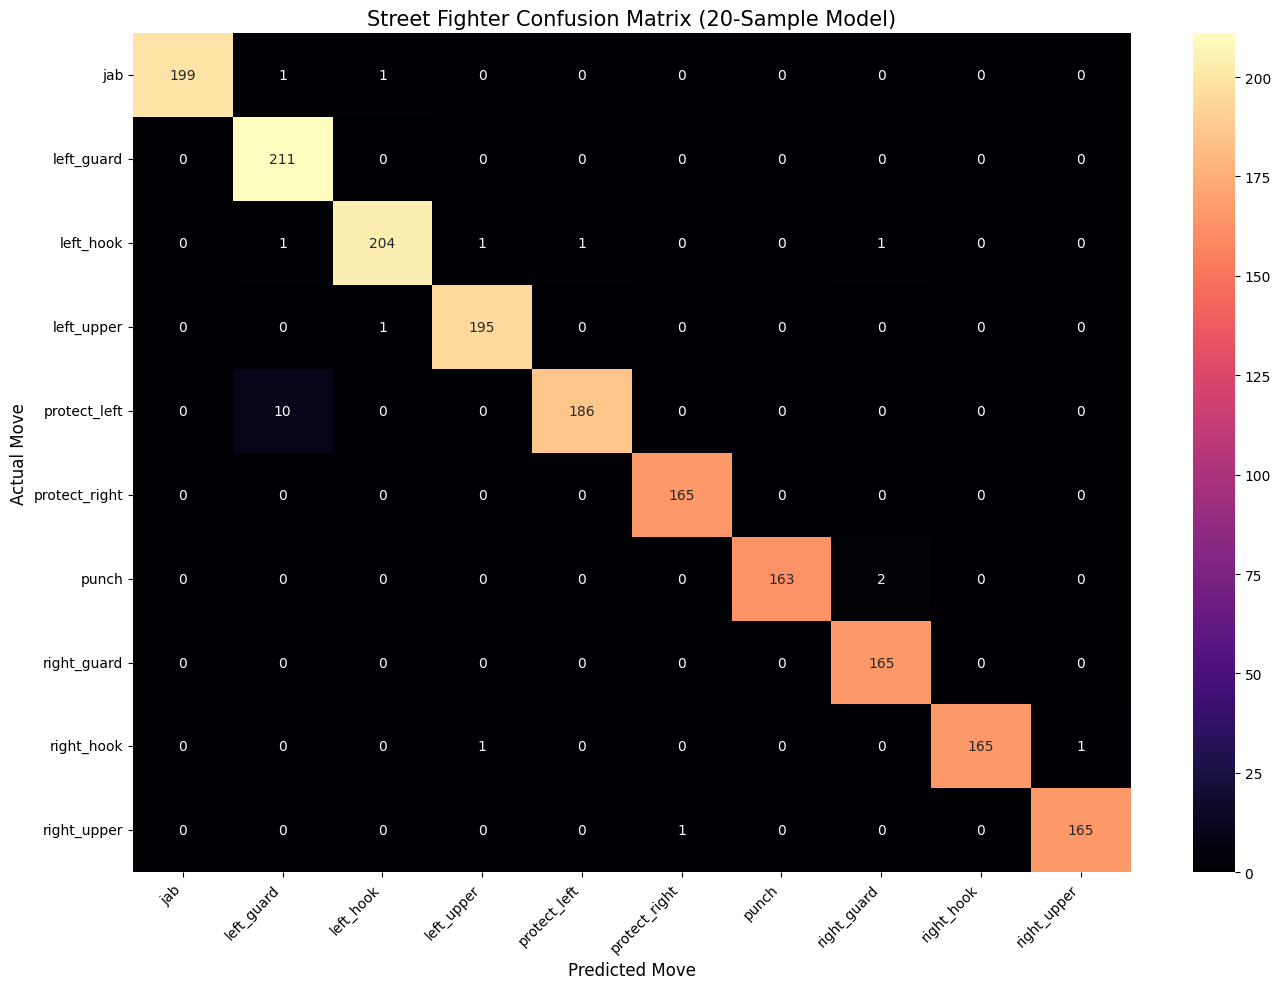


Per-Class Accuracy:
  jab: 99.00%
  left_guard: 100.00%
  left_hook: 98.08%
  left_upper: 99.49%
  protect_left: 94.90%
  protect_right: 100.00%
  punch: 98.79%
  right_guard: 100.00%
  right_hook: 98.80%
  right_upper: 99.40%

Detailed Classification Report:
               precision    recall  f1-score   support

          jab     1.0000    0.9900    0.9950       201
   left_guard     0.9462    1.0000    0.9724       211
    left_hook     0.9903    0.9808    0.9855       208
   left_upper     0.9898    0.9949    0.9924       196
 protect_left     0.9947    0.9490    0.9713       196
protect_right     0.9940    1.0000    0.9970       165
        punch     1.0000    0.9879    0.9939       165
  right_guard     0.9821    1.0000    0.9910       165
   right_hook     1.0000    0.9880    0.9940       167
  right_upper     0.9940    0.9940    0.9940       166

     accuracy                         0.9880      1840
    macro avg     0.9891    0.9885    0.9886      1840
 weighted avg     0.98

In [ ]:
import torch
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import joblib

def evaluate_street_fighter_model(
    model,
    test_loader,
    device,
    encoder_path="label_street_fighter_encoder.pkl",
    normalize_cm=False
):
    # Load label encoder
    try:
        le = joblib.load(encoder_path)
        class_names = list(le.classes_)
    except Exception as e:
        print(f"Warning: Could not load {encoder_path}: {e}")
        print("Using numeric class indices instead.")

        try:
            num_classes = model.model[-1].out_features
        except Exception:
            num_classes = 10

        class_names = [str(i) for i in range(num_classes)]

    criterion = torch.nn.CrossEntropyLoss()

    #Evaluation
    model.eval()
    all_preds = []
    all_labels = []
    total_loss = 0.0
    total_samples = 0

    print(f"Starting final evaluation on device: {device}")

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            preds = outputs.argmax(dim=1)

            batch_size = inputs.size(0)
            total_loss += loss.item() * batch_size
            total_samples += batch_size

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Convert to numpy and compute metrics
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    accuracy = (all_preds == all_labels).mean()
    avg_test_loss = total_loss / total_samples

    print(f"\nOVERALL TEST LOSS: {avg_test_loss:.4f}")
    print(f"OVERALL TEST ACCURACY: {accuracy * 100:.2f}%")

    #Confusion matrix
    cm = confusion_matrix(all_labels, all_preds)

    if normalize_cm:
        cm_display = cm.astype(np.float32) / cm.sum(axis=1, keepdims=True).clip(min=1)
        fmt = ".2f"
        title = "Normalized Confusion Matrix (20-Sample Model)"
    else:
        cm_display = cm
        fmt = "d"
        title = "Street Fighter Confusion Matrix (20-Sample Model)"

    plt.figure(figsize=(14, 10))
    sns.heatmap(
        cm_display,
        annot=True,
        fmt=fmt,
        cmap="magma",
        xticklabels=class_names,
        yticklabels=class_names
    )

    plt.xlabel("Predicted Move", fontsize=12)
    plt.ylabel("Actual Move", fontsize=12)
    plt.title(title, fontsize=15)
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

    # Per-class accuracy
    print("\nPer-Class Accuracy:")
    for i, class_name in enumerate(class_names):
        class_mask = (all_labels == i)
        if class_mask.sum() == 0:
            class_acc = 0.0
        else:
            class_acc = (all_preds[class_mask] == all_labels[class_mask]).mean()
        print(f"  {class_name}: {class_acc * 100:.2f}%")

    # Classification report
    print("\nDetailed Classification Report:")
    print(
        classification_report(
            all_labels,
            all_preds,
            target_names=class_names,
            digits=4,
            zero_division=0
        )
    )

    return accuracy, avg_test_loss, cm, all_labels, all_preds


# Run evaluation
test_accuracy, test_loss, cm, y_true, y_pred = evaluate_street_fighter_model(
    model,
    test_loader,
    device,
    encoder_path="label_street_fighter_encoder.pkl",
    normalize_cm=False
)

## Save model

In [ ]:
import os
import json
import torch
import joblib
import numpy as np
from google.colab import files
import shutil

EXPORT_DIR = "street_fighter_export"
os.makedirs(EXPORT_DIR, exist_ok=True)

# Save model weights
torch.save(
    model.state_dict(),
    os.path.join(EXPORT_DIR, "street_fighter_model_state_dict.pth")
)

# Save model config
model_config = {
    "model_name": "StreetFighterCNN",

    # INPUT
    "input_channels": 6,
    "input_length": 20,
    "target_rows": 20,

    # OUTPUT
    "num_classes": 10,

    # ARCHITECTURE
    "conv_blocks": [
        {
            "in_channels": 6,
            "out_channels": 64,
            "kernel_size": 5,
            "padding": 2,
            "pool": True,
            "pool_kernel": 2,
            "dropout": 0.15789805985107816
        },
        {
            "in_channels": 64,
            "out_channels": 32,
            "kernel_size": 3,
            "padding": 1,
            "pool": False,
            "dropout": 0.1981132230256581
        }
    ],

    "final_layer_in_features": 32,

    # TRAINING SETTINGS
    "optimizer_used_for_training": "AdamW",
    "learning_rate": 0.0048528224494085535,
    "weight_decay": 0.00021240029415410964,
    "label_smoothing": 0.002351253426949095,

    # DATA FORMAT
    "feature_order": ["ax", "ay", "az", "gx", "gy", "gz"]
}

with open(os.path.join(EXPORT_DIR, "model_config.json"), "w") as f:
    json.dump(model_config, f, indent=2)

# Save normalization stats
norm_stats = {
    "a_mean": np.asarray(a_mean, dtype=np.float32).tolist(),
    "a_std": np.asarray(a_std, dtype=np.float32).tolist(),
    "g_mean": np.asarray(g_mean, dtype=np.float32).tolist(),
    "g_std": np.asarray(g_std, dtype=np.float32).tolist(),

    "target_rows": 20,

    "accel_features": ["ax", "ay", "az"],
    "gyro_features": ["gx", "gy", "gz"]
}

with open(os.path.join(EXPORT_DIR, "normalization_stats.json"), "w") as f:
    json.dump(norm_stats, f, indent=2)

# Copy label encoder
src_encoder = "label_street_fighter_encoder.pkl"
dst_encoder = os.path.join(EXPORT_DIR, "label_street_fighter_encoder.pkl")

if os.path.exists(src_encoder):
    import shutil
    shutil.copy(src_encoder, dst_encoder)
else:
    raise FileNotFoundError("label_street_fighter_encoder.pkl not found.")

#Save full checkpoint
checkpoint = {
    "model_state_dict": model.state_dict(),
    "model_config": model_config,
    "normalization_stats": norm_stats
}

torch.save(
    checkpoint,
    os.path.join(EXPORT_DIR, "street_fighter_checkpoint.pth")
)


print("Exported files:")
for name in os.listdir(EXPORT_DIR):
    print(" -", name)

#Zip everything
zip_path = shutil.make_archive("street_fighter_export", "zip", EXPORT_DIR)
print("\nCreated zip:", zip_path)


files.download(zip_path)

Exported files:
 - street_fighter_checkpoint.pth
 - model_config.json
 - normalization_stats.json
 - label_street_fighter_encoder.pkl
 - street_fighter_model_state_dict.pth

Created zip: /content/street_fighter_export.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Download Test cases for Vitis HLS testing

In [ ]:
import os
import json
import random
import numpy as np
import pandas as pd
import joblib
from glob import glob
from scipy.interpolate import interp1d

#config
DATASET_ROOT = "/content/street_fighter_data/combined_final_clear"
EXPORT_FILE = "test_samples2.h"
SAMPLES_PER_CLASS = 2
TARGET_LEN = 20
RANDOM_SEED = 42

random.seed(RANDOM_SEED)

#Load normalisation and label encoder
with open("street_fighter_export/normalization_stats.json", "r") as f:
    norm_stats = json.load(f)

le = joblib.load("street_fighter_export/label_street_fighter_encoder.pkl")

a_mean = np.array(norm_stats["a_mean"], dtype=np.float32)
a_std  = np.array(norm_stats["a_std"], dtype=np.float32)
g_mean = np.array(norm_stats["g_mean"], dtype=np.float32)
g_std  = np.array(norm_stats["g_std"], dtype=np.float32)

FEATURES = ["ax", "ay", "az", "gx", "gy", "gz"]


def resample_to_length(data, target_len=20):
    old_len = data.shape[0]

    if old_len == target_len:
        return data.astype(np.float32)

    if old_len < 2:
        return np.repeat(data, target_len, axis=0).astype(np.float32)

    x_old = np.linspace(0, 1, old_len)
    x_new = np.linspace(0, 1, target_len)

    f = interp1d(x_old, data, axis=0, kind="linear", fill_value="extrapolate")
    return f(x_new).astype(np.float32)

def preprocess_for_hls(csv_path):
    df = pd.read_csv(csv_path)
    df.columns = df.columns.str.strip()

    for col in FEATURES:
        if col not in df.columns:
            raise ValueError(f"Missing column '{col}' in {csv_path}")

    # raw shape: (T, 6)
    data = df[FEATURES].to_numpy(dtype=np.float32)

    #resample to exactly 20 rows
    data = resample_to_length(data, TARGET_LEN)

    #z-score normalize exactly like training
    data[:, :3] = (data[:, :3] - a_mean) / a_std
    data[:, 3:] = (data[:, 3:] - g_mean) / g_std

    #transpose to (6, 20) for CNN / HLS
    data = data.T.astype(np.float32)

    return data

#collect 2 sample per class
samples = []

for class_name in sorted(os.listdir(DATASET_ROOT)):
    class_path = os.path.join(DATASET_ROOT, class_name)

    if not os.path.isdir(class_path):
        continue

    csv_files = sorted(glob(os.path.join(class_path, "*.csv")))

    if len(csv_files) < SAMPLES_PER_CLASS:
        print(f"⚠️ Skipping {class_name}: only {len(csv_files)} CSV files found")
        continue

    selected_files = random.sample(csv_files, SAMPLES_PER_CLASS)
    label_idx = int(le.transform([class_name])[0])

    for fpath in selected_files:
        processed = preprocess_for_hls(fpath)

        samples.append({
            "name": os.path.basename(fpath),
            "label": label_idx,
            "data": processed
        })

print(f"Collected {len(samples)} samples total")

#write to test_samples.h
with open(EXPORT_FILE, "w") as f:
    f.write("#ifndef TEST_SAMPLES_H\n")
    f.write("#define TEST_SAMPLES_H\n\n")

    f.write('#include "cnn_top.h"\n\n')

    f.write("typedef struct {\n")
    f.write("    const char* name;\n")
    f.write("    data_t data[IN_CH][IN_LEN];\n")
    f.write("    int target_label;\n")
    f.write("} test_sample_t;\n\n")

    f.write(f"#define NUM_TEST_SAMPLES {len(samples)}\n\n")

    f.write("static const test_sample_t test_samples[NUM_TEST_SAMPLES] = {\n")

    for i, s in enumerate(samples):
        f.write("    {\n")
        f.write(f'        "{s["name"]}",\n')
        f.write("        {\n")

        for c in range(6):
            row = ", ".join(f"{x:.6f}" for x in s["data"][c])
            if c < 5:
                f.write(f"            {{{row}}},\n")
            else:
                f.write(f"            {{{row}}}\n")

        f.write("        },\n")
        f.write(f"        {s['label']}\n")

        if i < len(samples) - 1:
            f.write("    },\n")
        else:
            f.write("    }\n")

    f.write("};\n\n")
    f.write("#endif\n")

print(f"✅ Exported {EXPORT_FILE}")

Collected 20 samples total
✅ Exported test_samples2.h


## Downlaoad weights to be used in Vitis HLS

In [ ]:
import torch
import numpy as np

#Load model
model = StreetFighterCNN(num_classes=10)
model.load_state_dict(torch.load("street_fighter_ultra96_model.pth", map_location="cpu"))
model.eval()

layers = list(model.model)

conv1 = layers[0]
bn1   = layers[1]

conv2 = layers[5]
bn2   = layers[6]

fc = layers[-1]

#BatchNorm folding
def fold_conv_bn(conv, bn):
    W = conv.weight.detach().cpu().numpy()
    b = conv.bias.detach().cpu().numpy() if conv.bias is not None else np.zeros(W.shape[0])

    gamma = bn.weight.detach().cpu().numpy()
    beta  = bn.bias.detach().cpu().numpy()
    mean  = bn.running_mean.detach().cpu().numpy()
    var   = bn.running_var.detach().cpu().numpy()
    eps   = bn.eps

    std = np.sqrt(var + eps)

    W_fold = W * (gamma / std)[:, None, None]
    b_fold = (b - mean) * (gamma / std) + beta

    return W_fold.astype(np.float32), b_fold.astype(np.float32)

#Fold layers
conv1_w, conv1_b = fold_conv_bn(conv1, bn1)
conv2_w, conv2_b = fold_conv_bn(conv2, bn2)

fc_w = fc.weight.detach().cpu().numpy().astype(np.float32)   # (10, 32)
fc_b = fc.bias.detach().cpu().numpy().astype(np.float32)

#Export to weights.h
with open("weight2s.h", "w") as f:

    f.write("#ifndef WEIGHTS_H\n")
    f.write("#define WEIGHTS_H\n\n")
    f.write('#include "cnn_top.h"\n\n')

    #CONV1
    f.write("static const data_t CONV1_W[64][6][5] = {\n")
    for o in range(64):
        f.write("    {\n")
        for i in range(6):
            row = ", ".join(f"{x:.6f}" for x in conv1_w[o, i])
            if i < 5:
                f.write(f"        {{{row}}},\n")
            else:
                f.write(f"        {{{row}}}\n")
        if o < 63:
            f.write("    },\n")
        else:
            f.write("    }\n")
    f.write("};\n\n")

    f.write("static const data_t CONV1_B[64] = {")
    f.write(", ".join(f"{x:.6f}" for x in conv1_b))
    f.write("};\n\n")

    #CONV2
    f.write("static const data_t CONV2_W[32][64][3] = {\n")
    for o in range(32):
        f.write("    {\n")
        for i in range(64):
            row = ", ".join(f"{x:.6f}" for x in conv2_w[o, i])
            if i < 63:
                f.write(f"        {{{row}}},\n")
            else:
                f.write(f"        {{{row}}}\n")
        if o < 31:
            f.write("    },\n")
        else:
            f.write("    }\n")
    f.write("};\n\n")

    f.write("static const data_t CONV2_B[32] = {")
    f.write(", ".join(f"{x:.6f}" for x in conv2_b))
    f.write("};\n\n")

    #FC
    f.write("static const data_t FC_W[10][32] = {\n")
    for o in range(10):
        row = ", ".join(f"{x:.6f}" for x in fc_w[o])
        if o < 9:
            f.write(f"    {{{row}}},\n")
        else:
            f.write(f"    {{{row}}}\n")
    f.write("};\n\n")

    f.write("static const data_t FC_B[10] = {")
    f.write(", ".join(f"{x:.6f}" for x in fc_b))
    f.write("};\n\n")

    f.write("#endif\n")

print("✅ weights.h generated successfully!")

✅ weights.h generated successfully!


## Load test samples for bit steam test

In [ ]:
import os
import json
import random
import shutil
from glob import glob
import joblib
import numpy as np
import pandas as pd
from scipy.interpolate import interp1d

# Config
DATASET_ROOT = "/content/street_fighter_data/combined_final_clear"
EXPORT_DIR = "street_fighter_export"
OUTPUT_FILE = "ultra96_test_samples.npz"
RAW_SAMPLES_DIR = "selected_raw_csv_files"

SAMPLES_PER_CLASS = 2
TARGET_LEN = 20
RANDOM_SEED = 42

# Current HLS input type -> ap_fixed<16,6>
FIXED_SCALE = 1024.0
FEATURES = ["ax", "ay", "az", "gx", "gy", "gz"]

random.seed(RANDOM_SEED)

# Create the export directories
os.makedirs(EXPORT_DIR, exist_ok=True)
os.makedirs(RAW_SAMPLES_DIR, exist_ok=True)

def resample_to_length(data: np.ndarray, target_len: int = 20) -> np.ndarray:
    old_len = data.shape[0]
    if old_len == target_len:
        return data.astype(np.float32)
    if old_len < 2:
        return np.repeat(data, target_len, axis=0).astype(np.float32)

    x_old = np.linspace(0, 1, old_len)
    x_new = np.linspace(0, 1, target_len)
    f = interp1d(x_old, data, axis=0, kind="linear", fill_value="extrapolate")
    return f(x_new).astype(np.float32)

def preprocess_csv(csv_path, a_mean, a_std, g_mean, g_std, target_len=20):
    df = pd.read_csv(csv_path)
    df.columns = df.columns.str.strip()

    # raw shape: (T, 6)
    data = df[FEATURES].to_numpy(dtype=np.float32)

    #Resample
    data = resample_to_length(data, target_len)

    #Normalize
    data[:, :3] = (data[:, :3] - a_mean) / a_std
    data[:, 3:] = (data[:, 3:] - g_mean) / g_std

    # Transpose to Channels, Time
    data_f32 = data.T.astype(np.float32)

    #Quantize for HLS (ap_fixed<16,6>)
    data_q = np.round(data_f32 * FIXED_SCALE).astype(np.int16)

    return data_f32, data_q

#Load normalisation and label encoder
with open(os.path.join(EXPORT_DIR, "normalization_stats.json"), "r") as f:
    norm_stats = json.load(f)

le = joblib.load(os.path.join(EXPORT_DIR, "label_street_fighter_encoder.pkl"))

a_mean = np.array(norm_stats["a_mean"], dtype=np.float32)
a_std  = np.array(norm_stats["a_std"], dtype=np.float32)
g_mean = np.array(norm_stats["g_mean"], dtype=np.float32)
g_std  = np.array(norm_stats["g_std"], dtype=np.float32)


names = []
class_names = []
labels = []
samples_f32 = []
samples_q16 = []

for class_name in sorted(os.listdir(DATASET_ROOT)):
    class_path = os.path.join(DATASET_ROOT, class_name)
    if not os.path.isdir(class_path):
        continue

    csv_files = sorted(glob(os.path.join(class_path, "*.csv")))
    if len(csv_files) < SAMPLES_PER_CLASS:
        print(f"Skipping {class_name}: not enough files.")
        continue

    # Select the random samples
    selected = random.sample(csv_files, SAMPLES_PER_CLASS)
    label_idx = int(le.transform([class_name])[0])

    # Create a subfolder for this class in the raw export directory
    class_raw_export_dir = os.path.join(RAW_SAMPLES_DIR, class_name)
    os.makedirs(class_raw_export_dir, exist_ok=True)

    for csv_path in selected:
        filename = os.path.basename(csv_path)

        dest_path = os.path.join(class_raw_export_dir, filename)
        shutil.copy(csv_path, dest_path)

        data_f32, data_q = preprocess_csv(
            csv_path, a_mean, a_std, g_mean, g_std, TARGET_LEN
        )

        names.append(filename)
        class_names.append(class_name)
        labels.append(label_idx)
        samples_f32.append(data_f32)
        samples_q16.append(data_q)

# Stack into numpy arrays
samples_f32 = np.stack(samples_f32, axis=0)   # (N, 6, 20)
samples_q16 = np.stack(samples_q16, axis=0)   # (N, 6, 20)
labels = np.array(labels, dtype=np.int32)
names = np.array(names, dtype=object)
class_names = np.array(class_names, dtype=object)

# Save the compressed NPZ
np.savez(
    OUTPUT_FILE,
    names=names,
    class_names=class_names,
    labels=labels,
    samples_f32=samples_f32,
    samples_q16=samples_q16
)

print("--- Extraction Complete ---")
print(f"Total samples processed: {len(labels)}")
print(f"Raw .csv files stored in: {RAW_SAMPLES_DIR}")
print(f"Quantized data saved to: {OUTPUT_FILE}")

--- Extraction Complete ---
Total samples processed: 20
Raw .csv files stored in: selected_raw_csv_files
Quantized data saved to: ultra96_test_samples.npz
